In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

Давайте подивимося, як LSTM можна використовувати для побудови нейронної мережі прогнозування часових.

Будемо працювати з задачею прогнозування кількості пасажирів міжнародних авіаліній. З цим набором даних ми вже працювали в лекції "Time Series Analysis" і ви зможете порівняти результати :)

Задача полягає в тому, щоб за заданими роком і місяцем передбачити кількість пасажирів міжнародних авіаліній в одиницях виміру 1,000. Дані охоплюють період з січня 1949 року по грудень 1960 року, тобто 12 років, зі 144 спостереженнями.

Це регресійна задача. Тобто, знаючи кількість пасажирів (в тисячах) за останні місяці, можна передбачити, якою буде кількість пасажирів у наступному місяці. Набір даних має лише одну характеристику: "Кількість пасажирів" - `Passengers`.

Далі вже наведений код для читання даних, але нам їх ще треба буде трошки обробити.

In [2]:
# Завантаження даних
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)
df.set_index('Month', inplace=True)
display(df.head())

,Passengers
Month,
1949-01,112
1949-02,118
1949-03,132
1949-04,129
1949-05,121


**Завдання 1.** Створіть змінну типу `numpy.ndarray`, яка містить значення кількості пасажирів в форматі `float32`. Такий формат даних нам треба для тренування нейромережі.

In [3]:
data = df['Passengers'].values.astype(np.float32)

print(type(data))
print(data.dtype)
print(data[:5])

<class 'numpy.ndarray'>
float32
[112. 118. 132. 129. 121.]


Очікуваний результат:
```array([112., 118., 132., 129., 121.], dtype=float32)```

**Завдання 2**. Розбийте дані на тренувальні і валідаційні у співвідношенні 67% йде у тренування, 33 - у валідацію. Памʼятаємо, що ми працюємо з tim series, відповідно, навчаємось на давніших, валідуємось - на новіших.

In [4]:
train_size = int(len(data) * 0.67)
train, test = data[:train_size], data[train_size:]

len(train), len(test)

(96, 48)

**Завдання 3**.

Реалізуйте функцію `create_dataset`, яка перетворить одномірний часовий ряд (набір даних) у формат, придатний для тренування нейромережі.

Функція повинна приймати два аргументи:
- `dataset` — numpy-масив часового ряду,
- `lookback` — кількість попередніх кроків, які використовуватимуться для передбачення.

Функція повинна повернути два **тензори** PyTorch:
- `X` — набір ознак (вікно попередніх значень),
- `y` — цільові значення (наступні після вікна кроки).

Дані ми будемо подавати моделі в наступному форматі:
`
tensor([[112.],
        [118.],
        [132.],
        [129.],
        [121.]])
`
Відповідно першою розмірністю буде йти розмір вхідного батча, а другою - розмір вхіднизх даних і в нас це 1, бо лише одне значення на вході щоразу.

Після виконання завдання запустіть код нижче. Ми будемо передбачати на основі кількості пасажирів в попередній день кількість пасажирів в наступний, тому `lookback == 1`.

In [5]:
def create_dataset(dataset, lookback):
    X, y = [], []
    for i in range(len(dataset) - lookback):
        X.append(dataset[i:i + lookback])
        y.append(dataset[i + lookback])
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    X = torch.from_numpy(X)
    y = torch.from_numpy(y)
    return X, y

In [6]:
lookback = 1
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([95, 1]) torch.Size([95])
torch.Size([47, 1]) torch.Size([47])


Очікуваний результат:
```
torch.Size([95, 1]) torch.Size([95, 1])
torch.Size([47, 1]) torch.Size([47, 1])
```

**Завдання 4**.

Зверніть увагу на розмірності в попередньому завданні. Ми
З допомогою модуля `torch.nn` опишіть клас `AirModel`, який є нейронною мережею для прогнозування кількості пасажирів за допомогою LSTM.

1. **Конструктор класу** повинен приймати параметри `hidden_size`, `num_layers` та ініціювати шари:
   - LSTM-шар з наступними параметрами:
     - `input_size` — кожна точка часового ряду є окремим входом,,
     - `hidden_size` — заданий в конструкторі класу мережі,
     - `num_layers=1` — кількість шарів LSTM, задана в конструкторі мережі,
     - `batch_first=True` — визначає, що першим виміром є розмір батчу.
   - Лінійний шар (`nn.Linear`) для перетворення виходу LSTM на прогноз однієї точки.

2. **Метод forward** повинен виконувати наступні дії:
   - Передати вхідний тензор через LSTM-шар і отримати виходи (ігноруючи приховані стани).
   - Пропустити вихід LSTM через лінійний шар для отримання остаточного прогнозу.

Створіть об'єкт класу `AirModel` зі значеннями параметрів `hidden_size=50`, `num_layers=1` і протестуйте роботу моделі на вхідному тензорі `tensor([[112.]])`. На цьому етапі ми маємо переконатись, що модель здатна генерувати передбачення з рандомно ініційованими вагами.

In [7]:
class AirModel(nn.Module):
    def __init__(self, hidden_size, num_layers):
        super(AirModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out


model = AirModel(hidden_size=50, num_layers=1)

x_sample = torch.tensor([[112.]], dtype=torch.float32)
y_pred = model(x_sample)
print(y_pred.shape)
print(y_pred)

torch.Size([1, 1])
tensor([[0.2635]], grad_fn=<AddmmBackward0>)


**Завдання 5**.

Створіть об'єкт DataLoader для завантаження даних, використовуючи тренувальні вибірки `X_train` та `y_train`. Ваш DataLoader повинен виконувати наступні вимоги:

1. Використовувати клас `TensorDataset`, щоб об'єднати тензори ознак `X_train` і цільових значень `y_train`.
2. Дані повинні завантажуватися невеликими батчами розміром 8 за допомогою параметра `batch_size`.
3. Використовувати параметр `shuffle=True`, щоб дані перемішувалися перед кожною епохою тренування.


In [8]:
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

for xb, yb in train_loader:
    print(xb.shape, yb.shape)
    break

torch.Size([8, 1]) torch.Size([8])


**Завдання 6**.

1. Реалізуйте навчання нейронної мережі `AirModel` для прогнозування часових рядів, використовуючи Adam-оптимізатор та функцію втрат MSE (середньоквадратичну похибку).
2. Створіть цикл тренування для 2000 епох, у якому на кожній епосі:
   - Виконуйте крок тренування моделі (прямий прохід, обчислення похибки, зворотний прохід і оновлення ваг).
   - Підраховуйте середню похибку на кожному батчі даних і зберігайте її у списку `losses`.
3. Раз на 100 епох проводьте валідацію моделі:
   - Перевіряйте модель на тренувальних та тестових даних без оновлення ваг.
   - Обчислюйте корінь середньоквадратичної похибки (RMSE) для тренувальної та тестової вибірок і виводьте результати на екран.
   
**Примітка:**
- Використовуйте вже створений `DataLoader` для отримання батчів даних.
- Валідацію виконуйте в режимі `eval()`, вимикаючи обчислення градієнтів з `torch.no_grad()`.

**Приклад виходу:**
```
Epoch 0: train RMSE 12.3456, test RMSE 15.6789
Epoch 100: train RMSE 9.8765, test RMSE 12.3456
...
```

In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

num_epochs = 2000
losses = []

for epoch in range(num_epochs):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        yb = yb.view(-1, 1)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    epoch_loss = sum(batch_losses) / len(batch_losses)
    losses.append(epoch_loss)

    if epoch % 100 == 0:
        model.eval()
        with torch.no_grad():
            train_preds = model(X_train)
            test_preds = model(X_test)

            train_rmse = torch.sqrt(
                criterion(train_preds, y_train.view(-1, 1))
            ).item()
            test_rmse = torch.sqrt(
                criterion(test_preds, y_test.view(-1, 1))
            ).item()

        print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")


Epoch 0: train RMSE 223.6903, test RMSE 420.0345
Epoch 100: train RMSE 74.9792, test RMSE 237.3422
Epoch 200: train RMSE 71.5238, test RMSE 221.9464
Epoch 300: train RMSE 71.1583, test RMSE 216.1723
Epoch 400: train RMSE 71.1491, test RMSE 215.1723
Epoch 500: train RMSE 71.1492, test RMSE 215.2011
Epoch 600: train RMSE 71.1491, test RMSE 215.1848
Epoch 700: train RMSE 71.1492, test RMSE 215.2410
Epoch 800: train RMSE 71.1491, test RMSE 215.0807
Epoch 900: train RMSE 71.1498, test RMSE 214.7981
Epoch 1000: train RMSE 71.1500, test RMSE 215.4378
Epoch 1100: train RMSE 71.1491, test RMSE 215.0575
Epoch 1200: train RMSE 71.5787, test RMSE 222.4325
Epoch 1300: train RMSE 71.1497, test RMSE 215.3689
Epoch 1400: train RMSE 71.1491, test RMSE 215.1510
Epoch 1500: train RMSE 71.1493, test RMSE 215.2584
Epoch 1600: train RMSE 71.1491, test RMSE 215.1734
Epoch 1700: train RMSE 71.1492, test RMSE 214.9670
Epoch 1800: train RMSE 71.1491, test RMSE 215.0714
Epoch 1900: train RMSE 71.1491, test RMSE 

**Завдання 7.** Побудуйте графік лосів. Зробіть висновок з графіку, чи навчилась модель?

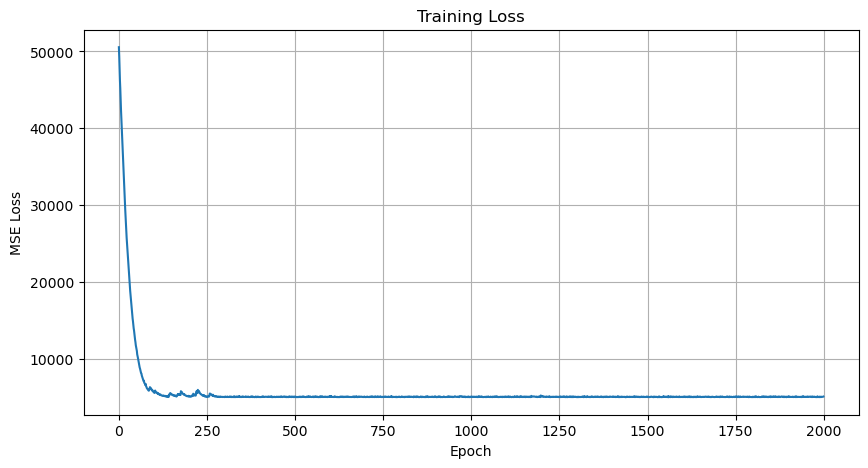

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

### Summary

The model's training loss drops sharply during the first ~200 epochs and then stabilizes at a low value, which shows that the LSTM successfully learned the overall trend in the training data.

However, the RMSE on the test set remains very high (~215).
Given that one data unit corresponds to **1,000 passengers**, this means the model's predictions on average differ from the actual values by **approximately 215,000 passengers**. This indicates that the model struggles to generalize on unseen data.

**Conclusion:**
Although the model learned the historical patterns, its forecasting accuracy is insufficient. The large test error suggests that the current configuration (lookback=1, no feature scaling) does not provide enough temporal context for reliable predictions on future periods.


Модель навчилась, але не факт, що точно)

Доволі неочікувано, що середньоквадратичне відхилення тестового набору даних буде на порядок більшим за одиниці в нашому наборі даних. Середньоквадратичне відхилення 100 означає, що прогноз і фактичне значення будуть відрізнятися в середньому на 100 (тобто, 100 000 пасажирів у цьому наборі даних).



Щоб краще зрозуміти якість прогнозу, ви можете побудувати графік з кодом нижче (а ще нижче - описано, що відбувається в цьому коді, бо це теж корисно зрозуміти):

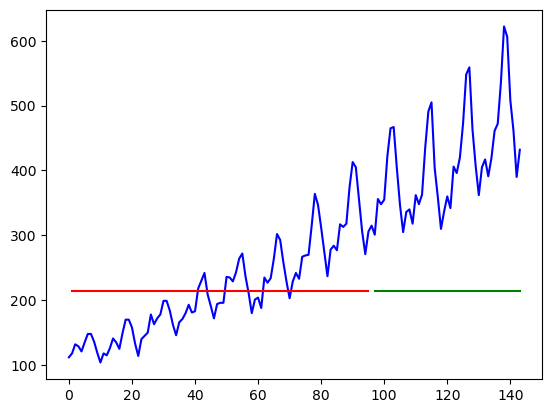

In [11]:
def plot_predicts(m):
    timeseries = data
    with torch.no_grad():
        # Зсув прогнозів для тренувальних даних
        train_plot = np.ones_like(timeseries) * np.nan
        y_pred = m(X_train)
        y_pred = y_pred[:, -1]
        train_plot[lookback:train_size] = m(X_train)[:, -1]

        # Зсув прогнозів для тестових даних
        test_plot = np.ones_like(timeseries) * np.nan
        test_plot[train_size + lookback:len(timeseries)] = m(X_test)[:, -1]

        # Візуалізація результатів
    plt.plot(timeseries, c='b')  # Реальні дані
    plt.plot(train_plot, c='r')  # Прогнози на тренувальних даних
    plt.plot(test_plot, c='g')  # Прогнози на тестових даних
    plt.show()

plot_predicts(model)

**Що відбувається в коді вище.** В цьому коді здійснюється процес прогнозування часових рядів за допомогою LSTM моделі, а також виведення графіку, який показує реальні значення, тренувальні та тестові прогнози. Ось що відбувається на кожному етапі:

1. **`torch.no_grad()`**: Цей контекстний менеджер вимикає обчислення градієнтів, що означає, що під час прогнозування не будуть зберігатися проміжні обчислення для зворотного проходу (backpropagation). Це підвищує ефективність під час прогнозування і зменшує використання пам'яті.

2. **Зсув прогнозів для тренувальних даних:**
   - Створюється масив `train_plot`, який має такий самий розмір, як і часовий ряд (`timeseries`), і заповнюється значеннями NaN (`np.nan`), щоб залишити місце для реальних значень.
   - Модель передбачає виходи для тренувальних даних `X_train`.
   - Використовується лише останнє передбачене значення для кожного входу LSTM (`y_pred[:, -1]`).
   - Прогнози зсуваються, починаючи з індексу `lookback` до кінця тренувальних даних (індекс `train_size`). Цей зсув потрібен, щоб зробити прогноз на основі попередніх даних і відобразити його на правильній частині графіку.

3. **Зсув прогнозів для тестових даних:**
   - Створюється масив `test_plot`, який також заповнюється NaN.
   - Прогнози для тестових даних додаються з індексу `train_size + lookback` до кінця реальних даних, щоб відобразити, де модель починає прогнозувати тестову вибірку.

4. **Побудова графіка:**
   - `plt.plot(timeseries, c='b')`: Виводить реальні значення часового ряду (синя лінія).
   - `plt.plot(train_plot, c='r')`: Виводить тренувальні прогнози (червона лінія).
   - `plt.plot(test_plot, c='g')`: Виводить тестові прогнози (зелена лінія).

**Чому це робиться:**
- Зсув прогнозів для тренувальних і тестових даних дозволяє візуально зрівняти, наскільки добре модель прогнозує як на тренувальній, так і на тестовій вибірках. Зазвичай, червона лінія (тренувальні прогнози) повинна точно відповідати синій лінії (реальні дані), а зелена лінія (тестові прогнози) дає змогу побачити, наскільки модель добре працює на нових даних, яких вона раніше не бачила.

**Завдання 8**. Навчіть модель з hidden_size=100 та порівняйте результати прогнозів з попередніми.

In [12]:
model_100 = AirModel(hidden_size=100, num_layers=1)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_100.parameters(), lr=0.01)

num_epochs = 2000
losses_100 = []

for epoch in range(num_epochs):
    model_100.train()
    batch_losses = []
    for xb, yb in train_loader:
        yb = yb.view(-1, 1)

        optimizer.zero_grad()
        preds = model_100(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    epoch_loss = sum(batch_losses) / len(batch_losses)
    losses_100.append(epoch_loss)

    if epoch % 100 == 0:
        model_100.eval()
        with torch.no_grad():
            train_preds = model_100(X_train)
            test_preds = model_100(X_test)

            train_rmse = torch.sqrt(
                criterion(train_preds, y_train.view(-1, 1))
            ).item()
            test_rmse = torch.sqrt(
                criterion(test_preds, y_test.view(-1, 1))
            ).item()

        print(f"Epoch {epoch}: train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")


Epoch 0: train RMSE 221.0188, test RMSE 417.2432
Epoch 100: train RMSE 71.5210, test RMSE 221.9249
Epoch 200: train RMSE 71.1493, test RMSE 215.2628
Epoch 300: train RMSE 71.1818, test RMSE 217.1199
Epoch 400: train RMSE 71.1495, test RMSE 215.3389
Epoch 500: train RMSE 71.1525, test RMSE 215.7597
Epoch 600: train RMSE 71.1492, test RMSE 214.9824
Epoch 700: train RMSE 71.1492, test RMSE 215.2332
Epoch 800: train RMSE 71.1530, test RMSE 215.7983
Epoch 900: train RMSE 71.1492, test RMSE 215.2245
Epoch 1000: train RMSE 71.1494, test RMSE 215.2925
Epoch 1100: train RMSE 71.1492, test RMSE 214.9738
Epoch 1200: train RMSE 71.1492, test RMSE 214.9860
Epoch 1300: train RMSE 71.1492, test RMSE 215.1951
Epoch 1400: train RMSE 71.1492, test RMSE 215.0098
Epoch 1500: train RMSE 71.1496, test RMSE 215.3584
Epoch 1600: train RMSE 71.1513, test RMSE 214.5826
Epoch 1700: train RMSE 71.1498, test RMSE 214.8169
Epoch 1800: train RMSE 71.1491, test RMSE 215.0210
Epoch 1900: train RMSE 71.1491, test RMSE 

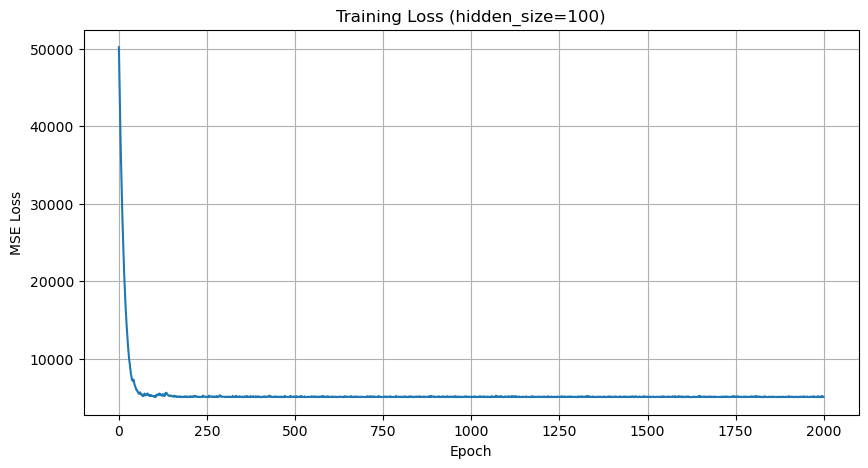

In [13]:
plt.figure(figsize=(10,5))
plt.plot(losses_100)
plt.title("Training Loss (hidden_size=100)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

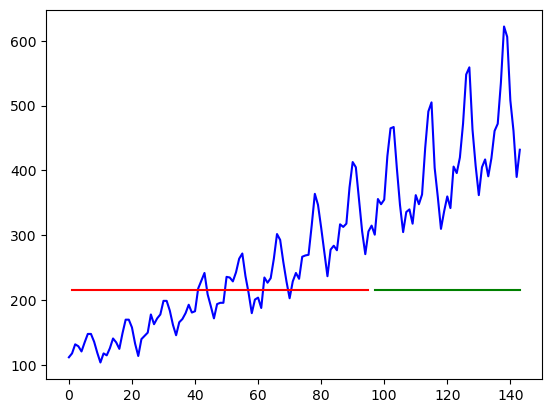

In [14]:
plot_predicts(model_100)

In [20]:
def run_experiment(lookback, hidden_size=100, num_epochs=2000, lr=0.01, batch_size=8):
    train_size = int(len(data) * 0.67)
    train, test = data[:train_size], data[train_size:]

    X_train, y_train = create_dataset(train, lookback)
    X_test, y_test = create_dataset(test, lookback)

    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model = AirModel(hidden_size=hidden_size, num_layers=1)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(num_epochs):
        model.train()
        batch_losses = []
        for xb, yb in train_loader:
            yb = yb.view(-1, 1)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        epoch_loss = sum(batch_losses) / len(batch_losses)
        losses.append(epoch_loss)

        if epoch % 100 == 0:
            model.eval()
            with torch.no_grad():
                train_preds = model(X_train)
                test_preds = model(X_test)
                train_rmse = torch.sqrt(criterion(train_preds, y_train.view(-1, 1))).item()
                test_rmse = torch.sqrt(criterion(test_preds, y_test.view(-1, 1))).item()
            print(f"Epoch {epoch}: lookback {lookback}, train RMSE {train_rmse:.4f}, test RMSE {test_rmse:.4f}")

    return model, losses, X_train, y_train, X_test, y_test, train_size

In [22]:
def plot_predicts_model(model, lookback, X_train, X_test, train_size):
    with torch.no_grad():
        timeseries = data

        train_plot = np.ones_like(timeseries) * np.nan
        train_preds = model(X_train).numpy().flatten()
        train_plot[lookback:train_size] = train_preds

        test_plot = np.ones_like(timeseries) * np.nan
        test_preds = model(X_test).numpy().flatten()
        test_plot[train_size+lookback:len(timeseries)] = test_preds

    plt.figure(figsize=(12, 5))
    plt.plot(timeseries, c='b', label="Real")
    plt.plot(train_plot, c='r', label="Train Predict")
    plt.plot(test_plot, c='g', label="Test Predict")
    plt.legend()
    plt.title(f"AirPassengers Predictions (lookback={lookback})")
    plt.show()


Running lookback=1, hidden_size=50
Epoch 0: lookback 1, train RMSE 223.5739, test RMSE 419.9310
Epoch 100: lookback 1, train RMSE 74.5151, test RMSE 235.9092
Epoch 200: lookback 1, train RMSE 72.4043, test RMSE 227.6875
Epoch 300: lookback 1, train RMSE 71.1493, test RMSE 215.2485
Epoch 400: lookback 1, train RMSE 71.1491, test RMSE 215.1582
Epoch 500: lookback 1, train RMSE 71.1494, test RMSE 215.3068
Epoch 600: lookback 1, train RMSE 71.1493, test RMSE 215.2672
Epoch 700: lookback 1, train RMSE 71.1492, test RMSE 215.1939
Epoch 800: lookback 1, train RMSE 71.1491, test RMSE 215.1120
Epoch 900: lookback 1, train RMSE 71.1491, test RMSE 215.0722
Epoch 1000: lookback 1, train RMSE 71.1496, test RMSE 215.3633
Epoch 1100: lookback 1, train RMSE 71.1491, test RMSE 215.0260
Epoch 1200: lookback 1, train RMSE 71.1491, test RMSE 215.1682
Epoch 1300: lookback 1, train RMSE 71.1491, test RMSE 215.0359
Epoch 1400: lookback 1, train RMSE 71.1491, test RMSE 215.0823
Epoch 1500: lookback 1, train R

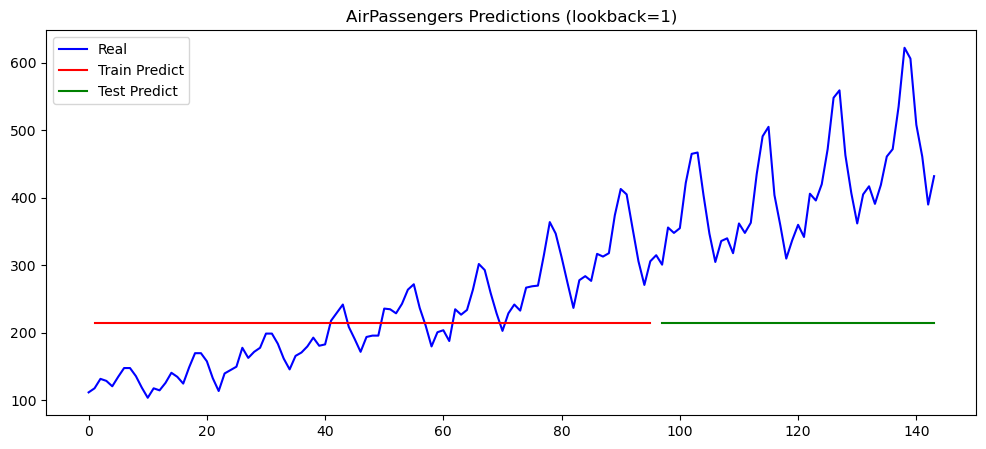

Running lookback=1, hidden_size=100
Epoch 0: lookback 1, train RMSE 220.4671, test RMSE 416.7231
Epoch 100: lookback 1, train RMSE 71.5705, test RMSE 222.3652
Epoch 200: lookback 1, train RMSE 71.5341, test RMSE 222.0397
Epoch 300: lookback 1, train RMSE 71.1509, test RMSE 214.6211
Epoch 400: lookback 1, train RMSE 71.1491, test RMSE 215.1832
Epoch 500: lookback 1, train RMSE 71.4201, test RMSE 220.9180
Epoch 600: lookback 1, train RMSE 71.1492, test RMSE 214.9689
Epoch 700: lookback 1, train RMSE 71.1491, test RMSE 215.0456
Epoch 800: lookback 1, train RMSE 71.1502, test RMSE 215.4821
Epoch 900: lookback 1, train RMSE 71.1492, test RMSE 215.1996
Epoch 1000: lookback 1, train RMSE 71.1491, test RMSE 215.0214
Epoch 1100: lookback 1, train RMSE 71.1494, test RMSE 215.2934
Epoch 1200: lookback 1, train RMSE 71.1491, test RMSE 215.1172
Epoch 1300: lookback 1, train RMSE 71.1492, test RMSE 214.9832
Epoch 1400: lookback 1, train RMSE 71.1496, test RMSE 215.3636
Epoch 1500: lookback 1, train 

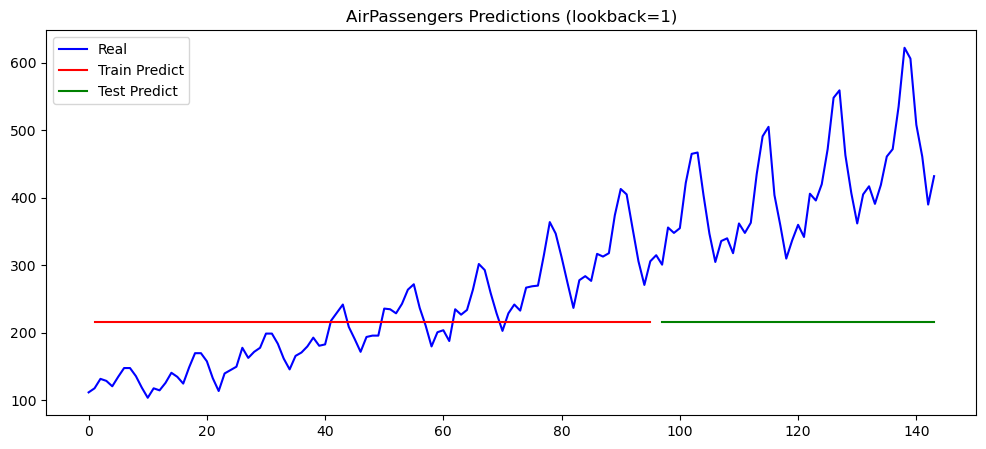

Running lookback=3, hidden_size=50
Epoch 0: lookback 3, train RMSE 224.1460, test RMSE 422.4642
Epoch 100: lookback 3, train RMSE 56.2129, test RMSE 207.4108
Epoch 200: lookback 3, train RMSE 39.0463, test RMSE 167.2867
Epoch 300: lookback 3, train RMSE 33.1106, test RMSE 153.6911
Epoch 400: lookback 3, train RMSE 29.0462, test RMSE 135.7393
Epoch 500: lookback 3, train RMSE 26.5158, test RMSE 117.7307
Epoch 600: lookback 3, train RMSE 27.4564, test RMSE 128.4200
Epoch 700: lookback 3, train RMSE 27.8159, test RMSE 128.1549
Epoch 800: lookback 3, train RMSE 26.2972, test RMSE 123.1692
Epoch 900: lookback 3, train RMSE 26.5854, test RMSE 115.6520
Epoch 1000: lookback 3, train RMSE 27.0331, test RMSE 124.3090
Epoch 1100: lookback 3, train RMSE 25.1774, test RMSE 120.3978
Epoch 1200: lookback 3, train RMSE 25.1017, test RMSE 118.1413
Epoch 1300: lookback 3, train RMSE 27.7298, test RMSE 130.6003
Epoch 1400: lookback 3, train RMSE 27.7159, test RMSE 127.0041
Epoch 1500: lookback 3, train R

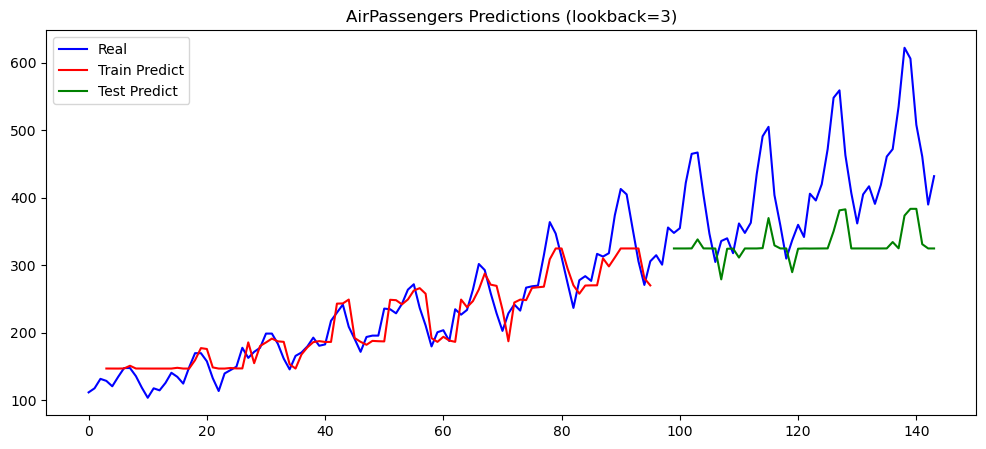

Running lookback=3, hidden_size=100
Epoch 0: lookback 3, train RMSE 219.6639, test RMSE 418.0527
Epoch 100: lookback 3, train RMSE 38.5446, test RMSE 167.6000
Epoch 200: lookback 3, train RMSE 32.3487, test RMSE 152.5908
Epoch 300: lookback 3, train RMSE 30.1127, test RMSE 143.0392
Epoch 400: lookback 3, train RMSE 25.0678, test RMSE 116.9327
Epoch 500: lookback 3, train RMSE 24.3789, test RMSE 113.2184
Epoch 600: lookback 3, train RMSE 26.1017, test RMSE 120.1895
Epoch 700: lookback 3, train RMSE 26.1976, test RMSE 124.3345
Epoch 800: lookback 3, train RMSE 23.5127, test RMSE 102.4782
Epoch 900: lookback 3, train RMSE 23.7158, test RMSE 101.6509
Epoch 1000: lookback 3, train RMSE 25.3848, test RMSE 93.1534
Epoch 1100: lookback 3, train RMSE 22.0995, test RMSE 96.6336
Epoch 1200: lookback 3, train RMSE 26.5228, test RMSE 126.8517
Epoch 1300: lookback 3, train RMSE 24.6056, test RMSE 109.8918
Epoch 1400: lookback 3, train RMSE 24.1204, test RMSE 110.4243
Epoch 1500: lookback 3, train RM

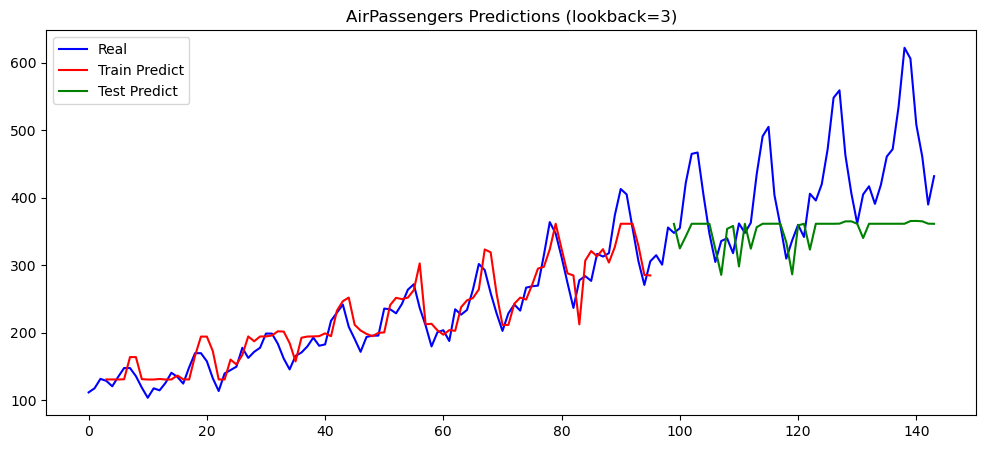

Running lookback=12, hidden_size=50
Epoch 0: lookback 12, train RMSE 233.0054, test RMSE 432.4611
Epoch 100: lookback 12, train RMSE 58.2198, test RMSE 219.5055
Epoch 200: lookback 12, train RMSE 40.5711, test RMSE 173.9920
Epoch 300: lookback 12, train RMSE 34.8357, test RMSE 158.0607
Epoch 400: lookback 12, train RMSE 30.6192, test RMSE 145.3896
Epoch 500: lookback 12, train RMSE 24.2684, test RMSE 127.7447
Epoch 600: lookback 12, train RMSE 23.2105, test RMSE 113.4144
Epoch 700: lookback 12, train RMSE 23.6751, test RMSE 115.7650
Epoch 800: lookback 12, train RMSE 22.8674, test RMSE 107.1356
Epoch 900: lookback 12, train RMSE 20.9541, test RMSE 101.9604
Epoch 1000: lookback 12, train RMSE 21.2006, test RMSE 100.7749
Epoch 1100: lookback 12, train RMSE 23.4913, test RMSE 98.8210
Epoch 1200: lookback 12, train RMSE 23.7781, test RMSE 108.9071
Epoch 1300: lookback 12, train RMSE 20.9911, test RMSE 100.8236
Epoch 1400: lookback 12, train RMSE 20.0550, test RMSE 101.0030
Epoch 1500: look

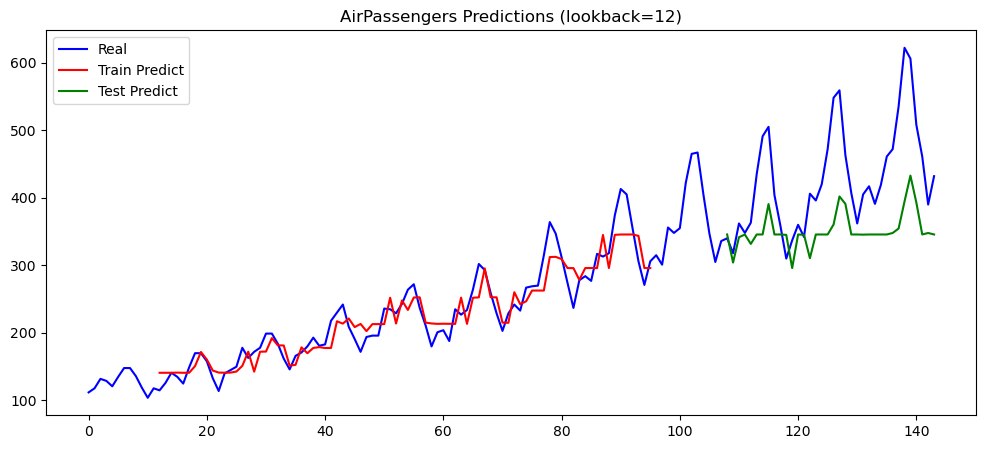

Running lookback=12, hidden_size=100
Epoch 0: lookback 12, train RMSE 229.5612, test RMSE 429.0394
Epoch 100: lookback 12, train RMSE 41.1204, test RMSE 179.5097
Epoch 200: lookback 12, train RMSE 30.7801, test RMSE 148.5670
Epoch 300: lookback 12, train RMSE 28.0986, test RMSE 139.1126
Epoch 400: lookback 12, train RMSE 24.5173, test RMSE 121.5364
Epoch 500: lookback 12, train RMSE 22.6167, test RMSE 115.2549
Epoch 600: lookback 12, train RMSE 22.1474, test RMSE 102.2705
Epoch 700: lookback 12, train RMSE 22.4293, test RMSE 96.9263
Epoch 800: lookback 12, train RMSE 23.4471, test RMSE 100.8383
Epoch 900: lookback 12, train RMSE 21.4464, test RMSE 109.7110
Epoch 1000: lookback 12, train RMSE 26.6303, test RMSE 124.3619
Epoch 1100: lookback 12, train RMSE 25.1098, test RMSE 115.5140
Epoch 1200: lookback 12, train RMSE 23.9017, test RMSE 104.4351
Epoch 1300: lookback 12, train RMSE 23.5442, test RMSE 88.8411
Epoch 1400: lookback 12, train RMSE 22.1834, test RMSE 99.1733
Epoch 1500: lookb

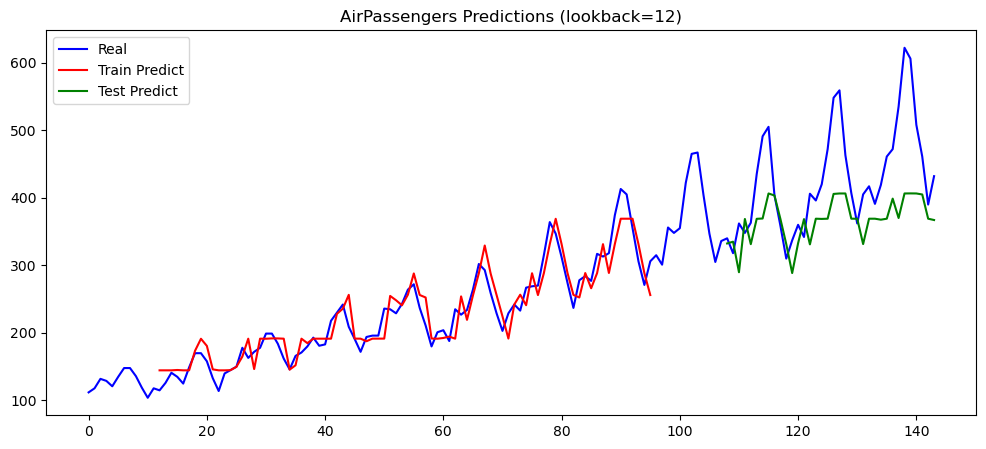

Running lookback=24, hidden_size=50
Epoch 0: lookback 24, train RMSE 245.5691, test RMSE 455.5528
Epoch 100: lookback 24, train RMSE 66.9663, test RMSE 248.5083
Epoch 200: lookback 24, train RMSE 61.9938, test RMSE 224.9575
Epoch 300: lookback 24, train RMSE 61.9917, test RMSE 224.3995
Epoch 400: lookback 24, train RMSE 61.9918, test RMSE 224.5878
Epoch 500: lookback 24, train RMSE 60.0298, test RMSE 228.0781
Epoch 600: lookback 24, train RMSE 56.9379, test RMSE 216.5597
Epoch 700: lookback 24, train RMSE 54.4985, test RMSE 212.6517
Epoch 800: lookback 24, train RMSE 52.2437, test RMSE 209.0452
Epoch 900: lookback 24, train RMSE 50.1488, test RMSE 204.3941
Epoch 1000: lookback 24, train RMSE 48.2121, test RMSE 201.6755
Epoch 1100: lookback 24, train RMSE 46.5470, test RMSE 199.3982
Epoch 1200: lookback 24, train RMSE 44.9853, test RMSE 196.1121
Epoch 1300: lookback 24, train RMSE 43.6793, test RMSE 192.1903
Epoch 1400: lookback 24, train RMSE 42.2628, test RMSE 188.9368
Epoch 1500: loo

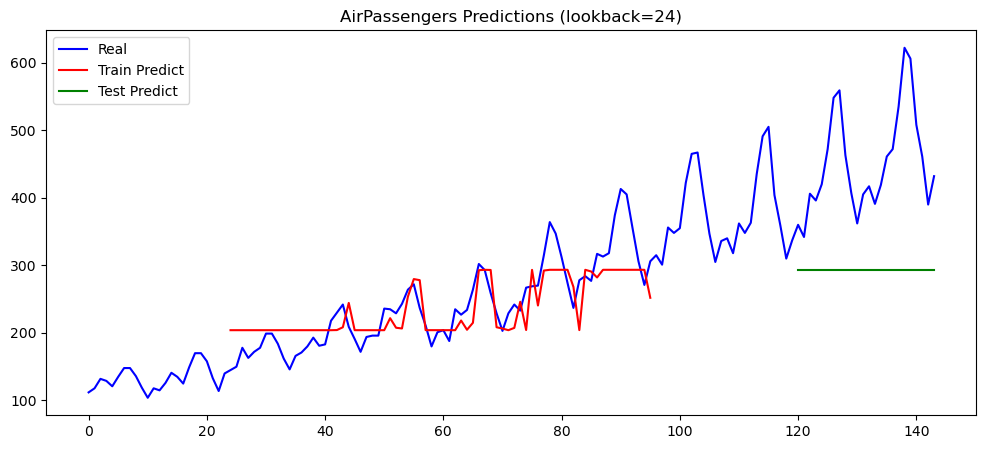

Running lookback=24, hidden_size=100
Epoch 0: lookback 24, train RMSE 243.1379, test RMSE 453.3473
Epoch 100: lookback 24, train RMSE 61.9933, test RMSE 224.9052
Epoch 200: lookback 24, train RMSE 56.9822, test RMSE 217.2324
Epoch 300: lookback 24, train RMSE 52.7527, test RMSE 209.8228
Epoch 400: lookback 24, train RMSE 48.9448, test RMSE 204.8692
Epoch 500: lookback 24, train RMSE 45.7233, test RMSE 200.5705
Epoch 600: lookback 24, train RMSE 42.7501, test RMSE 194.2587
Epoch 700: lookback 24, train RMSE 39.5466, test RMSE 187.8399
Epoch 800: lookback 24, train RMSE 37.2504, test RMSE 183.2021
Epoch 900: lookback 24, train RMSE 35.4285, test RMSE 179.9396
Epoch 1000: lookback 24, train RMSE 34.4394, test RMSE 175.3142
Epoch 1100: lookback 24, train RMSE 35.6985, test RMSE 178.5624
Epoch 1200: lookback 24, train RMSE 35.3383, test RMSE 174.9068
Epoch 1300: lookback 24, train RMSE 34.3447, test RMSE 171.2473
Epoch 1400: lookback 24, train RMSE 33.7474, test RMSE 168.7476
Epoch 1500: lo

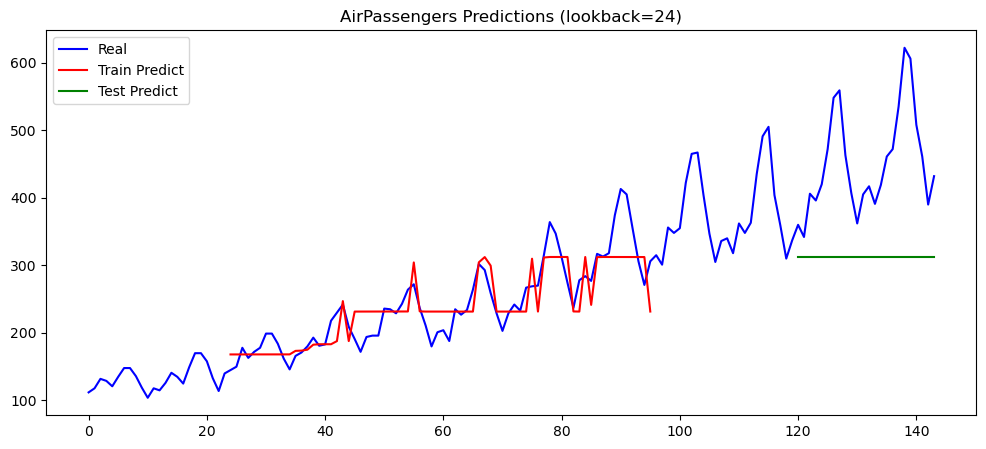

Running lookback=36, hidden_size=50
Epoch 0: lookback 36, train RMSE 259.2855, test RMSE 480.2331
Epoch 100: lookback 36, train RMSE 92.3909, test RMSE 302.7680
Epoch 200: lookback 36, train RMSE 58.6369, test RMSE 242.0984
Epoch 300: lookback 36, train RMSE 57.9668, test RMSE 233.8298
Epoch 400: lookback 36, train RMSE 57.9668, test RMSE 233.5605
Epoch 500: lookback 36, train RMSE 57.9667, test RMSE 233.8003
Epoch 600: lookback 36, train RMSE 57.9712, test RMSE 233.0112
Epoch 700: lookback 36, train RMSE 57.9688, test RMSE 234.1714
Epoch 800: lookback 36, train RMSE 57.9918, test RMSE 235.3209
Epoch 900: lookback 36, train RMSE 57.9667, test RMSE 233.6383
Epoch 1000: lookback 36, train RMSE 57.9676, test RMSE 233.3899
Epoch 1100: lookback 36, train RMSE 57.9667, test RMSE 233.7701
Epoch 1200: lookback 36, train RMSE 57.9690, test RMSE 234.2011
Epoch 1300: lookback 36, train RMSE 57.9670, test RMSE 233.5114
Epoch 1400: lookback 36, train RMSE 57.9672, test RMSE 233.4542
Epoch 1500: loo

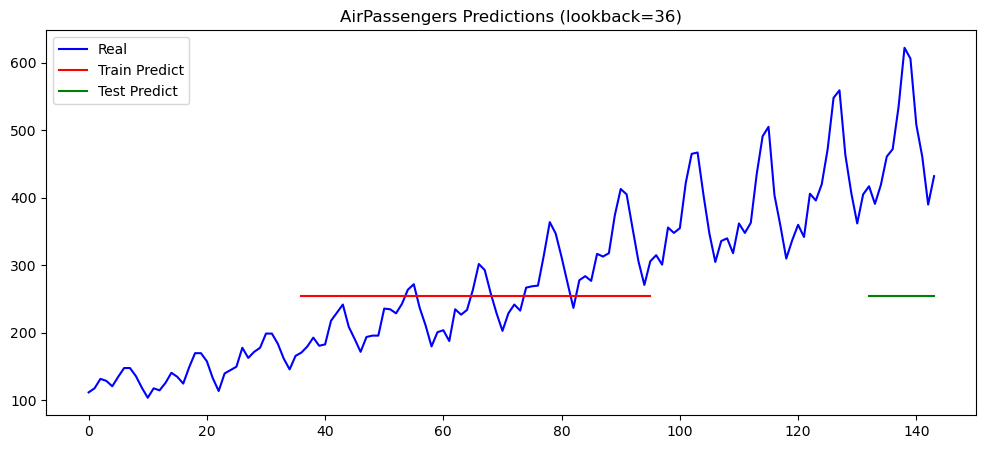

Running lookback=36, hidden_size=100
Epoch 0: lookback 36, train RMSE 256.7165, test RMSE 477.6242
Epoch 100: lookback 36, train RMSE 58.1138, test RMSE 237.6227
Epoch 200: lookback 36, train RMSE 57.9673, test RMSE 233.9525
Epoch 300: lookback 36, train RMSE 57.9670, test RMSE 233.5040
Epoch 400: lookback 36, train RMSE 57.9705, test RMSE 234.3386
Epoch 500: lookback 36, train RMSE 57.9716, test RMSE 232.9829
Epoch 600: lookback 36, train RMSE 57.9681, test RMSE 234.0863
Epoch 700: lookback 36, train RMSE 57.6698, test RMSE 235.8440
Epoch 800: lookback 36, train RMSE 53.4667, test RMSE 227.1943
Epoch 900: lookback 36, train RMSE 51.2577, test RMSE 223.5334
Epoch 1000: lookback 36, train RMSE 49.3966, test RMSE 220.8658
Epoch 1100: lookback 36, train RMSE 47.8291, test RMSE 217.5578
Epoch 1200: lookback 36, train RMSE 46.2912, test RMSE 215.0130
Epoch 1300: lookback 36, train RMSE 45.1252, test RMSE 212.9152
Epoch 1400: lookback 36, train RMSE 44.2193, test RMSE 210.8452
Epoch 1500: lo

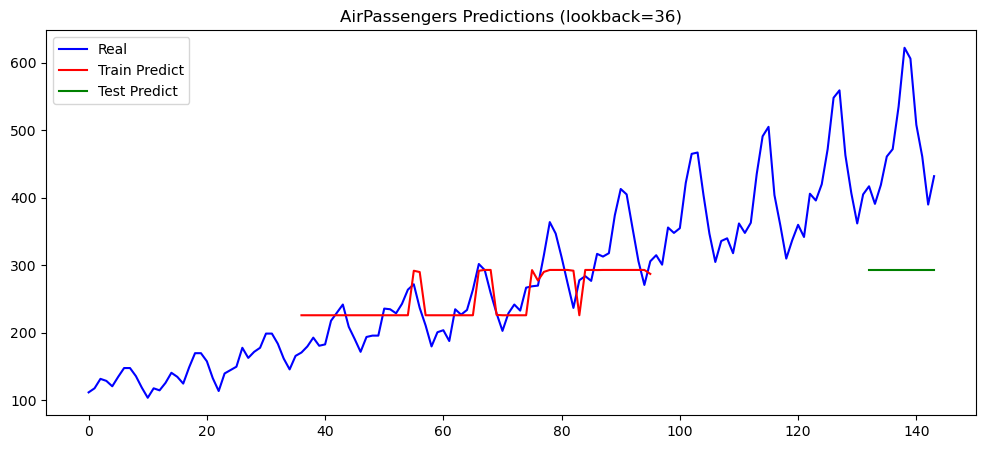

In [23]:
lookbacks = [1, 3, 12, 24, 36]
hidden_sizes = [50, 100]

results = {}

for lb in lookbacks:
    for hs in hidden_sizes:
        print("="*50)
        print(f"Running lookback={lb}, hidden_size={hs}")
        print("="*50)

        model, losses, Xtr, ytr, Xte, yte, tr_size = run_experiment(
            lookback=lb,
            hidden_size=hs,
            num_epochs=2000,
            lr=0.01,
            batch_size=8
        )

        results[(lb, hs)] = (model, losses, Xtr, ytr, Xte, yte, tr_size)

        plot_predicts_model(model, lb, Xtr, Xte, tr_size)


## Summary

We experimented with LSTM models to predict the monthly number of airline passengers, testing multiple configurations:

- `lookback` values: **1, 3, 12, 24, 36**
- `hidden_size`: **50** and **100**

### Key Observations from the Experiments

| Lookback | Train Fit | Test Fit | Notes |
|---------:|:---------:|:--------:|------|
| **1** | ❌ Flat constant prediction | ❌ Flat constant prediction | Model sees no trend or seasonality |
| **3** | ⚠ Better fit | ⚠ Slight seasonal hints | Still does not capture long-term growth |
| **12** | ✔ Captures yearly seasonality | ⚠ Trend still underestimated | Best balance among tested values |
| **24** | ⚠ Too few training samples | ❌ Very weak prediction | Model struggles to generalize |
| **36** | ❌ Severe underfitting | ❌ Almost flat outputs | Training set becomes too small |

### Effect of Hidden Layer Size

| Hidden Size | Result |
|------------|--------|
| **50** | Baseline fit |
| **100** | Almost no visible improvement |

Increasing model capacity does **not** help much if the model lacks **input context** or data scaling.

---

### Final Conclusion

- **Lookback matters far more than hidden_size** in this task.
- **lookback=12** performs the best, as one full seasonal cycle becomes visible.
- Models still **fail to capture the upward trend** because data is not normalized and the input context remains limited.

---

### Final Takeaway

> The current LSTM setup learns seasonal fluctuations but does not fully understand the long-term growth trend. Proper preprocessing and richer temporal context are required for accurate forecasting.

